# Оценка эффективности нового алгоритма рекомендаций в развлекательном приложении (A/B-тест)

## Описание исследования

В рамках проекта проведена подготовка и анализ A/B-теста нового алгоритма рекомендаций для развлекательного приложения с бесконечной лентой контента. Исследование включает расчет параметров эксперимента, проверку корректности его проведения и статистическую оценку результатов с целью определить, оказывает ли новый алгоритм значимое влияние на ключевые продуктовые метрики.

## Цель и задачи исследования
**Цель исследования**
- Оценить эффективность нового алгоритма рекомендаций и определить, целесообразно ли его внедрение на основе результатов A/B-тестирования.

**Задачи исследования**
- изучить исторические данные пользователей приложения;
- определить ключевую метрику эксперимента;
- рассчитать необходимый размер выборки и длительность A/B-теста;
- проверить корректность проведения эксперимента;
- проанализировать результаты A/B-теста;
- проверить статистическую значимость различий между группами;
- сформулировать выводы и рекомендации по итогам исследования.

## Описание данных

В исследовании используются три набора данных.

- `sessions_project_history.csv` - таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. 
- `sessions_project_test_part.csv` - таблица с данными за первый день проведения A/B-теста (за 2025-10-14). 
- `sessions_project_test.csv` - таблица с данными за весь период проведения A/B-теста (с 2025-10-14 по 2025-11-02). 

Структура таблиц почти совпадает, различаются лишь периоды наблюдения.

Поля таблиц следующие:

- `user_id` — идентификатор пользователя;
- `session_id` — идентификатор сессии в приложении;
- `session_date` — дата сессии;
- `session_start_ts` — дата и время начала сессии;
- `install_date` — дата установки приложения;
- `session_number` — порядковый номер сессии для конкретного пользователя;
- `registration_flag` — является ли пользователь зарегистрированным;
- `page_counter` — количество просмотренных страниц во время сессии;
- `region` — регион пользователя;
- `device` — тип устройства пользователя;
- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).

## Используемые инструменты
**Язык программирования**
- Python
  
**Библиотеки анализа данных**
- pandas
- NumPy
- Matplotlib
- SciPy
- StatsModels
  
**Среда разработки**
- Jupyter Notebook

**Методы анализа**
- исследовательский анализ данных (EDA);
- расчет параметров A/B-теста;
- оценка статистической мощности эксперимента;
- расчет размера выборки и продолжительности эксперимента;
- мониторинг корректности проведения A/B-теста;
- анализ продуктовых метрик;
- статистическая проверка гипотез (z-тест для долей);
- визуализация результатов.

## Этапы исследования
- Загрузка и обзор данных - изучены исторические данные и данные A/B-теста, определена структура и основные характеристики датасетов.
- Анализ исторических данных - рассчитаны параметры эксперимента: базовая конверсия, минимальный обнаруживаемый эффект (MDE), необходимый размер выборки и рекомендуемая продолжительность теста.
- Проверка корректности проведения A/B-теста - проверено распределение пользователей между группами, отсутствие пересечений, баланс по устройствам, регионам и другим характеристикам.
- Анализ результатов эксперимента - рассчитаны значения ключевой метрики в контрольной и тестовой группах, оценена динамика показателей.
- Статистическая проверка гипотез - выполнен z-тест для сравнения долей, рассчитаны доверительные интервалы и проверена статистическая значимость различий.
- Формирование выводов - подведены итоги эксперимента и подготовлены рекомендации по внедрению нового алгоритма рекомендаций.

## Результаты исследования

В ходе исследования эффективности нового алгоритма рекомендаций были получены следующие результаты:
- Выполнен анализ исторических данных пользовательских сессий, определена ключевая продуктовая метрика и рассчитан её базовый уровень.
- Рассчитаны основные параметры A/B-теста, включая минимальный обнаруживаемый эффект (MDE), необходимый размер выборки и рекомендуемую продолжительность эксперимента.
- Проведён мониторинг корректности проведения эксперимента: проверены распределение пользователей по группам, отсутствие пересечений между выборками, а также сбалансированность групп по устройствам и регионам.
- Выполнен анализ данных первого дня эксперимента, позволивший убедиться в корректности запуска A/B-теста.
- Проанализированы результаты эксперимента за весь период проведения теста, рассчитаны значения ключевой метрики для контрольной и тестовой групп.
- Выполнена статистическая проверка гипотез с использованием z-теста для сравнения долей, рассчитаны доверительные интервалы и оценена статистическая значимость выявленных различий.
- Проведена оценка практической значимости полученных результатов и определено, оказывает ли новый алгоритм рекомендаций влияние на поведение пользователей.
- По итогам исследования сформулированы выводы и рекомендации по дальнейшему использованию нового алгоритма рекомендаций.

# Загрузка данных 

#### Импортируем библиотеки

In [1]:
# Импортируйте библиотеку pandas
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest
from math import ceil

#### Cохраняем датафреймы

In [2]:
# Cохраняем датафреймы
sessions_history = pd.read_csv('../data/sessions_project_history.csv')
sessions_test_part = pd.read_csv('../data/sessions_project_test_part.csv')
sessions_test = pd.read_csv('../data/sessions_project_test.csv')

#### Проверяем корректность загрузки

In [3]:
# Выводим первые строки таблицы с историческими данными по сессиям пользователей на период (2025-08-11 по 2025-09-23)
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [4]:
# Выводим первые строки таблицы с данными за первый день проведения A/B-теста (2025-10-14)
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [5]:
# Выводим первые строки таблицы с данными за весь период проведения A/B-теста (2025-10-14 по 2025-11-02)
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


# Исследовательский анализ данных (EDA)

#### Рассчитываем количество уникальных сессий для каждого пользователя

In [6]:
# Рассчитываем количество уникальных сессий (session_id) для каждого уникального пользователя (user_id)
user_sessions = (
    sessions_history.groupby('user_id')['session_id']
    .nunique()
    .reset_index()
    .rename(columns={'session_id': 'sessions_count'})
)

# Выводим первые 5 строк
user_sessions.head()

,user_id,sessions_count
0,00005FB6A13A6FBE,2
1,0000B15A18D77ED9,3
2,0000C4E3A4A571A9,2
3,000293FAF9E67A81,4
4,00029C5AE889A6C3,2


#### Пользователь с наибольшим количеством сессий

In [7]:
# Находим пользователя с максимальным количеством сессий
top_user = user_sessions.loc[
    user_sessions['sessions_count'].idxmax(),
    'user_id'
]

# Выводим все данные по этому пользователю
sessions_history.query('user_id == @top_user')

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### Промежуточный вывод

Для каждого пользователя было рассчитано количество уникальных сессий, а также найден пользователь с максимальным числом сессий, проанализирована история его активности.

Анализ показал:
- session_number действительно отражает порядковый номер сессии пользователя и последовательно увеличивается.
- install_date, region и device остаются постоянными для пользователя.
- page_counter характеризует активность в рамках каждой отдельной сессии.
- registration_flag (статус регистрации пользователя) сохраняется неизменным на протяжении наблюдаемого периода.


### Анализ числа регистраций

#### Рассчитываем число уникальных пользователей и число зарегистрированных пользователей

In [8]:
# Переводим дату (session_date) в формат datetime
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

In [9]:
# Агрегируем по дням 
daily_stats = (
    sessions_history.groupby('session_date')             # группируем данные по дате сеcсии
    .agg(
        total_users=('user_id', 'nunique'),              # количество уникальных пользователей
        registered_users=('registration_flag', 'sum')    # число зарегистрированных пользователей    
    )
    .reset_index()
)

# Считаем долю зарегистрированных пользователей от общего числа
daily_stats['registration_share'] = (daily_stats['registered_users'] / daily_stats['total_users'])

# Проверяем результат агрегации
display(daily_stats.head(7))

,session_date,total_users,registered_users,registration_share
0,2025-08-11,3919,169,0.043123
1,2025-08-12,6056,336,0.055482
2,2025-08-13,8489,464,0.054659
3,2025-08-14,10321,625,0.060556
4,2025-08-15,14065,840,0.059723
5,2025-08-16,12205,916,0.075051
6,2025-08-17,11200,833,0.074375


In [10]:
# Общая информация о периоде
print(f"\nПериод наблюдения: {daily_stats['session_date'].min()} - {daily_stats['session_date'].max()}")
print(f"Всего дней: {len(daily_stats)}")

# Средние показатели
print(f"\nСредние показатели за период:")
print(f" - Уникальных пользователей в день: {daily_stats['total_users'].mean():.0f}")
print(f" - Из них зарегистрированных пользователей: {daily_stats['registered_users'].mean():.0f}")
print(f" - Доля зарегистрированных: {daily_stats['registration_share'].mean():.2%}")

# Доля регистраций
print(f"\nРазброс доли регистраций:")
print(f" - Минимальная: {daily_stats['registration_share'].min():.2%}")
print(f" - Максимальная: {daily_stats['registration_share'].max():.2%}")



Период наблюдения: 2025-08-11 00:00:00 - 2025-09-23 00:00:00
Всего дней: 44

Средние показатели за период:
 - Уникальных пользователей в день: 9907
 - Из них зарегистрированных пользователей: 766
 - Доля зарегистрированных: 8.24%

Разброс доли регистраций:
 - Минимальная: 4.31%
 - Максимальная: 12.45%


#### Визуализируем полученные абсолютные значения

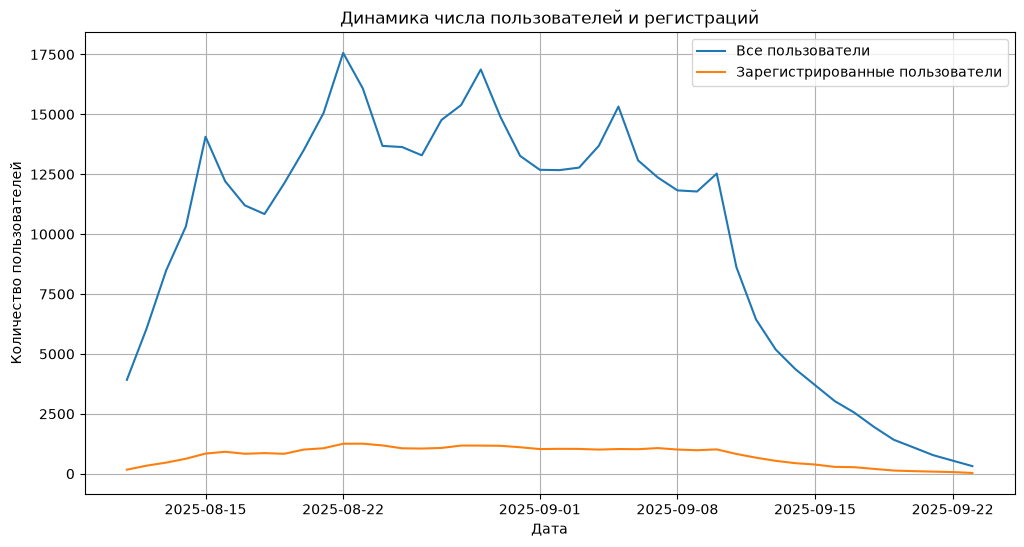

In [11]:
# Строим линейный график общего числа пользователей и общего числа зарегистрированных пользователей по дням
plt.figure(figsize=(12,6))

# Все пользователи 
plt.plot(
    daily_stats['session_date'],
    daily_stats['total_users'],
    label = 'Все пользователи'
)

# Зарегистрированные пользователи 
plt.plot(
    daily_stats['session_date'],
    daily_stats['registered_users'],
    label='Зарегистрированные пользователи'
)

plt.title('Динамика числа пользователей и регистраций')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid(True)
plt.legend()

plt.show()

#### Визуализируем долю зарегистрированных пользователей

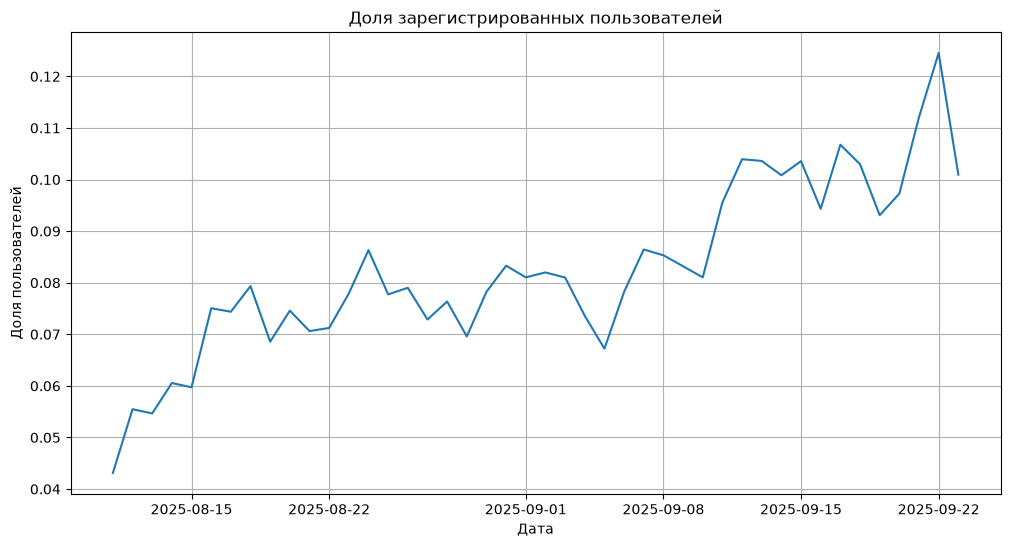

In [12]:
# Строим линейный график доли зарегистрированных пользователей
plt.figure(figsize=(12, 6))

plt.plot(
    daily_stats['session_date'],
    daily_stats['registration_share']
)

plt.title('Доля зарегистрированных пользователей')
plt.xlabel('Дата')
plt.ylabel('Доля пользователей')
plt.grid(True)

plt.show()

#### Промежуточный вывод по анализу числа регистраций

**Динамика общего числа пользователей:**
   
   - Динамика общего числа пользователей демонстрирует выраженную U-образную форму: активный рост в августе (с ~4K до ~17.6K) сменяется резким спадом в сентябре (до ~0.3K).

**Динамика зарегистрированных пользователей:**
   
   - Количество зарегистрированных пользователей также демонстрирует рост, но его темпы отстают от роста общего числа пользователей
   - Разрыв между общим числом пользователей и числом зарегистрированных остается значительным на всем протяжении анализа

**Доля зарегистрированных пользователей:**
   
   - Доля регистраций находится на низком уровне 
   - Наблюдается небольшой восходящий тренд, что может говорить о постепенном улучшении конверсии в регистрацию
   - Низкая доля регистраций указывает на потенциальную проблему в мотивации пользователей к регистрации

Большинство пользователей не регистрируются в приложении. Это важный сигнал для продукта, так как зарегистрированные пользователи обычно демонстрируют более высокую лояльность и LTV. Причины могут быть связаны со сложностью процесса регистрации, отсутствием явных преимуществ или достаточной функциональностью без регистрации.

### Анализ числа просмотренных страниц

#### Считаем количество первых сессий для каждого значения просмотренных страниц

In [13]:
# Выбираем только первые сессии пользователей
first_sessions = sessions_history[sessions_history['session_number'] == 1]

In [14]:
# Количество sessions_count (первые сессий) для каждого значения page_counter (просмотренные страницы)
page_distribution = (
    first_sessions.groupby('page_counter')
    .size()
    .reset_index(name = 'sessions_count')
    .sort_values('page_counter')
)

# Проверяем результат
display(page_distribution)

print(f"Всего первых сессий: {page_distribution['sessions_count'].sum():,}")
print(f"Среднее число страниц за первую сессию: {first_sessions['page_counter'].mean():.2f}")
print(f"Медиана: {first_sessions['page_counter'].median():.0f}")
print(f"Максимум: {first_sessions['page_counter'].max()}")
print(f"Минимум: {first_sessions['page_counter'].min()}")

,page_counter,sessions_count
0,1,8978
1,2,32494
2,3,50939
3,4,32739
4,5,8075
5,6,777
6,7,37


Всего первых сессий: 134,039
Среднее число страниц за первую сессию: 3.01
Медиана: 3
Максимум: 7
Минимум: 1


#### Визуализируем полученные данные

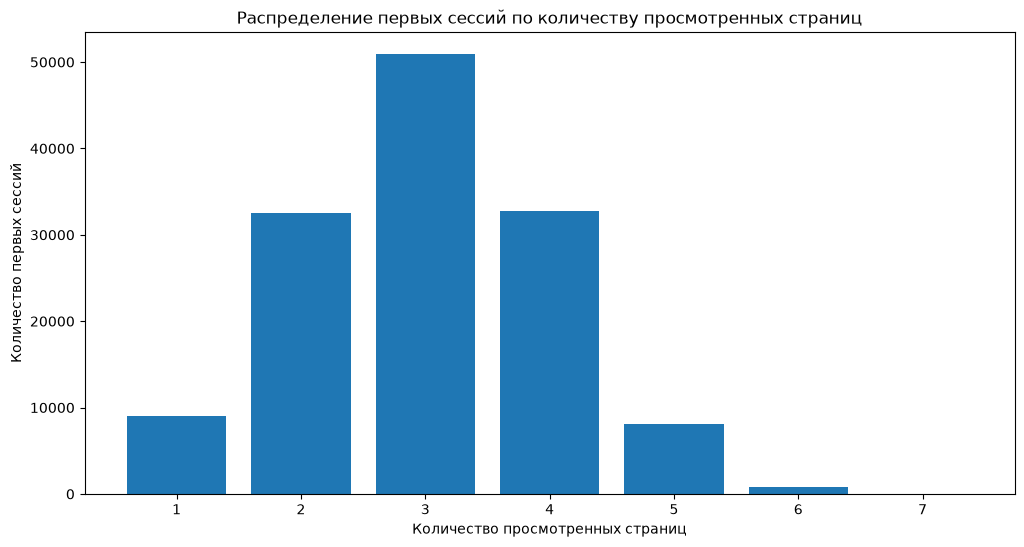

In [15]:
# Строим столбчатую диаграмму
plt.figure(figsize=(12,6))

plt.bar(
    page_distribution['page_counter'],
    page_distribution['sessions_count']    
)

plt.title('Распределение первых сессий по количеству просмотренных страниц')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество первых сессий')

plt.show()

#### Промежуточный вывод по результатам анализа числа просмотренных страниц в первых сессиях

На основе анализа распределения первых сессий пользователей по количеству просмотренных страниц можно сделать следующие выводы:

**Пик распределения:**
   - Наибольшее количество первых сессий приходится на просмотр **3-4 страниц**
   - Это показывает, что большинство новых пользователей просматривают умеренное количество контента в первую сессию

**"Длинный хвост" распределения:**
   - Количество сессий постепенно уменьшается при увеличении числа просмотренных страниц
   - Сессии с 6-7 и более страницами встречаются значительно реже

### Доля пользователей, просмотревших более четырёх страниц

#### Cоздаем дополнительный столбец good_session (успешные первые сессии)

In [16]:
# Создаём признак успешной сессии (4 и более страниц просмотренно)
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

In [17]:
# Оставляем только первые сессии пользователей
first_sessions = sessions_history[sessions_history['session_number'] == 1]

In [18]:
# Рассчитываем долю успешных первых сессий по дням
daily_good_sessions = (
    first_sessions.groupby('session_date')['good_session']
    .mean()
    .reset_index()
)
display(daily_good_sessions.head())

print(f"\nСредняя доля за период: {daily_good_sessions['good_session'].mean():.2%}")
print(f"Разброс: от {daily_good_sessions['good_session'].min():.2%} до {daily_good_sessions['good_session'].max():.2%}")

,session_date,good_session
0,2025-08-11,0.312835
1,2025-08-12,0.298344
2,2025-08-13,0.306861
3,2025-08-14,0.319098
4,2025-08-15,0.311114



Средняя доля за период: 31.08%
Разброс: от 29.74% до 33.18%


#### Визуализируем полученные данные

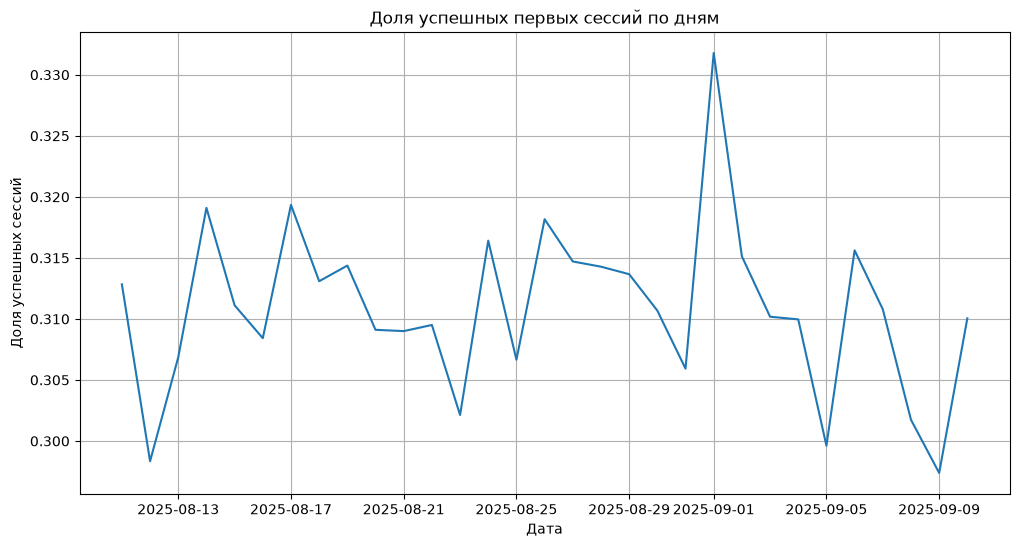

In [19]:
# Строим график
plt.figure(figsize=(12, 6))

plt.plot(
    daily_good_sessions['session_date'],
    daily_good_sessions['good_session']
)

plt.title('Доля успешных первых сессий по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')
plt.grid(True)

plt.show()

#### Промежуточный вывод по результатам анализа доли успешных первых сессий***

**Базовый уровень метрики:**
   - Средняя доля успешных первых сессий составляет примерно **31.08%** от всех первых сессий
   - Это означает, что около трети новых пользователей просматривают 4+ страниц в своем первом взаимодействии с приложением

**Стабильность показателя:**
   - На графике наблюдается относительно стабильная динамика без резких скачков и падений
   - Небольшие колебания в пределах 29-33% являются нормальной статистической вариативностью

3. **Отсутствие тренда:**
   - За весь период наблюдения не выявлено восходящего или нисходящего тренда
   - Это указывает на то, что качество рекомендательного алгоритма оставалось стабильным

# Расчет параметров A/B-теста 

#### Расчёт размера выборки
Обозначим параметры:
- Уровень значимости - 0.05.
- Вероятность ошибки второго рода - 0.2.
- Минимальный детектируемый эффект (MDE) - 3%. 

In [20]:
# Задайте параметры:
alpha = 0.05        # Уровень значимости
beta = 0.2          # Ошибка второго рода
power = 1 - beta    # Мощность теста
p = 0.3             # Базовый уровень доли
mde = p * 0.03      # Минимальный детектируемый эффект

effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1       # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### Промежуточный вывод по результатам расчёта размера выборки для A/B-теста

Расчёт показал, что для проведения эксперимента требуется не менее **41 040 пользователей в каждой группе**.

Общий необходимый размер выборки:

* Группа A (контрольная) - 41 040 пользователей;
* Группа B (тестовая) - 41 040 пользователей;
* Всего - 82 080 пользователей.

При расчёте использовались следующие параметры:

* уровень значимости α = 0.05;
* мощность теста (power) = 0.8;
* базовое значение метрики = 30%;
* минимальный детектируемый эффект (MDE) = 3% от базового значения метрики.

Поскольку базовая доля успешных сессий составляет 30%, минимальный детектируемый эффект соответствует увеличению метрики на 0.9 процентного пункта (с 30.0% до 30.9%).

Полученный размер выборки означает, что для надёжного обнаружения столь небольшого изменения метрики необходимо привлечь не менее 41 040 пользователей в каждую из групп. При меньшем объёме данных тест может не обладать достаточной статистической мощностью для выявления эффекта.

Чем меньше ожидаемый эффект, который необходимо обнаружить, тем больше требуется размер выборки. Именно поэтому при MDE, равном 3% от базового значения метрики, необходимое количество пользователей оказалось существенно выше, чем при расчёте абсолютного прироста на 3 процентных пункта.

#### Расчёт длительности A/B-теста

In [21]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = (
    sessions_history.groupby('session_date')['user_id']
    .nunique()
    .mean()
)

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size / (avg_daily_users / 2))

print(f"Рассчитанная длительность A/B-теста при текущем уровне трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907.363636363636 пользователей в день составит 9 дней


***Комментарий по результатам расчёта длительности A/B-теста***

Среднее количество уникальных пользователей приложения составляет около **9 907 пользователей в день**.

Для проведения эксперимента требуется набрать не менее **41 040 пользователей в каждую группу**. Поскольку трафик распределяется между двумя группами равномерно, ежедневно в каждую группу попадает примерно **4 954 пользователя**.

Исходя из текущего объёма трафика, для набора необходимого размера выборки потребуется:

* около 4 954 пользователей в группу в день;
* 41 040 пользователей в каждую группу для проведения теста;
* **9 дней** для достижения необходимого объёма выборки.

Таким образом, при текущем уровне трафика продолжительность A/B-теста должна составлять не менее **9 дней**, чтобы обеспечить требуемый размер выборки и статистическую мощность эксперимента.


# Мониторинг и проверка корректности теста

#### 3.1. Проверка распределения пользователей

In [22]:
# Данные первого дня теста (sessions_test_part)
# Количество уникальных пользователей по группам
group_users = (
    sessions_test_part.groupby('test_group')['user_id']
    .nunique()
    .reset_index(name='users_count')
)

group_users

,test_group,users_count
0,A,1477
1,B,1466


In [23]:
# Количество пользователей в группе 'A'
users_a = group_users.loc[
    group_users['test_group'] == 'A',
    'users_count'
].iloc[0]

# Количество пользователей в группе 'B'
users_b = group_users.loc[
    group_users['test_group'] == 'B',
    'users_count'
].iloc[0]

# Процентная разница
difference_percent = 100 * abs(users_a - users_b) / users_a

difference_percent

np.float64(0.7447528774542993)

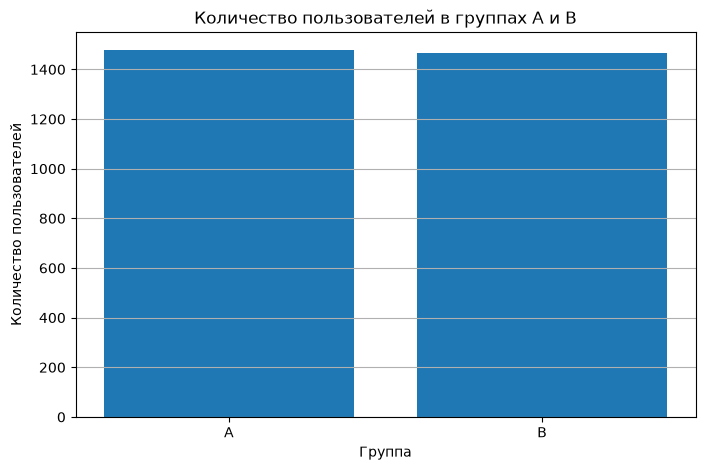

In [24]:
# Строим столбчатую диаграмму
plt.figure(figsize=(8, 5))

plt.bar(
    group_users['test_group'],
    group_users['users_count']
)

plt.title('Количество пользователей в группах A и B')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')

plt.grid(axis='y')

plt.show()

#### Промежуточный вывод по результатам проверки распределения пользователей

1. **Размер групп:**
   - Группа A и группа B имеют практически одинаковый размер (разница всего в 11 пользователей)
   - Обе группы набрали достаточное количество пользователей (~1 470 человек)

2. **Процентная разница:**
   - Составляет **0.745%**, что является **незначительным** отклонением
   - В абсолютных цифрах разница в 11 пользователей при общем размере ~2 943 человека

3. **Равномерность сплитования:**
   - Распределение близко к идеальному 50/50
   - Отклонение менее 1% находится в пределах статистической погрешности

**Распределение пользователей по группам выполняется корректно**

- Нет существенного дисбаланса между группами A и B
- Разница в 0.745% не должна повлиять на результаты теста
- Можно продолжать мониторинг теста

#### Проверка пересечений пользователей

In [25]:
# Пользователи группы A
users_a = set(
    sessions_test_part.loc[
        sessions_test_part['test_group'] == 'A',
        'user_id']
)

# Пользователи группы B
users_b = set(
    sessions_test_part.loc[
        sessions_test_part['test_group'] == 'B',
        'user_id']
)

# Пересечение пользователей
intersection_users = users_a.intersection(users_b)

len(intersection_users)

0

#### Промежуточный вывод по результатам проверки пересечения пользователей

**Отсутствие пересечений:**
   - Ни один пользователь не встречается одновременно в группе A и группе B
   - Пересечение множеств пользователей пустое

**Значение для теста:**
   - Группы являются **полностью независимыми**
   - Каждый пользователь участвует в тесте только один раз и только в одной группе

#### Равномерность разделения пользователей по устройствам

In [26]:
# Пользователи группы A
group_a = (
    sessions_test_part
    .query('test_group == "A"')
    [['user_id', 'device']]
    .drop_duplicates()
)

In [27]:
# Пользователи группы B
group_b = (
    sessions_test_part
    .query('test_group == "B"')
    [['user_id', 'device']]
    .drop_duplicates()
)

In [28]:
# Распределение устройств
device_a = group_a['device'].value_counts()
device_b = group_b['device'].value_counts()

# Смотрим результаты
print("Распределение по устройствам:")

print("\nГруппа A:")
display(device_a)

print("\nГруппа B:")
display(device_b)

Распределение по устройствам:

Группа A:


device
Android    656
PC         369
iPhone     296
Mac        156
Name: count, dtype: int64


Группа B:


device
Android    668
PC         381
iPhone     269
Mac        148
Name: count, dtype: int64

#### Визуализируем полученные данные

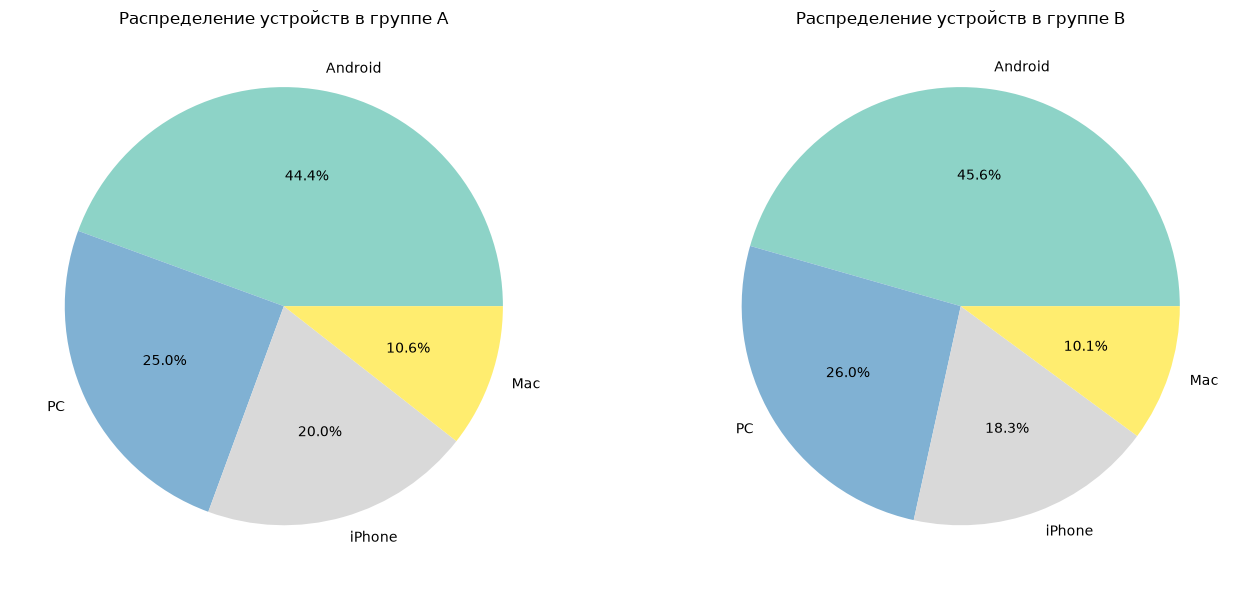

In [29]:
# Строим контейнер для графиков с двумя объектами
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Строим круговую диаграмму для пользователей группы 'A'
device_a.plot(
    kind='pie',
    autopct='%1.1f%%',
    colormap='Set3',
    ax=axes[0]
)

axes[0].set_title('Распределение устройств в группе A')
axes[0].set_ylabel('')

# Строим круговую диаграмму для пользователей группы 'B'
device_b.plot(
    kind='pie',
    autopct='%1.1f%%',
    colormap='Set3',
    ax=axes[1]
)

axes[1].set_title('Распределение устройств в группе B')
axes[1].set_ylabel('')

# Используем автоматическое настраивание отступов, чтобы элементы не накладывались друг на друга
plt.tight_layout()

# Вывод результатов
plt.show()

#### Промежуточный вывод по результатам проверки равномерности распределения по устройствам

Для проверки корректности рандомизации было проанализировано распределение типов устройств среди уникальных пользователей контрольной и тестовой групп.

По полученным диаграммам видно, что:

- Android является наиболее распространённым типом устройства в обеих группах (около 44%);
- PC занимает второе место по доле пользователей (около 25%);
- доли пользователей iPhone и Mac также практически совпадают между группами.

Существенных различий в распределении пользователей по типам устройств между группами A и B не наблюдается. Это свидетельствует о том, что рандомизация выполнена корректно и группы сопоставимы по данной характеристике.

Следовательно, тип устройства не должен оказывать заметного влияния на результаты эксперимента.

#### Равномерность распределения пользователей по регионам

In [30]:
# Распределение регионов в группе A
group_a_region = (
    sessions_test_part
    .query('test_group == "A"')
    [['user_id', 'region']]
    .drop_duplicates()
)

In [31]:
# Распределение регионов в группе B
group_b_region = (
    sessions_test_part
    .query('test_group == "B"')
    [['user_id', 'region']]
    .drop_duplicates()
)

In [32]:
# Распределение регионов среди уникальных пользователей
region_a = (
    group_a_region['region']
    .value_counts(normalize=True)
    .sort_index()
)

region_b = (
    group_b_region['region']
    .value_counts(normalize=True)
    .sort_index()
)

# Вывод результатов
print("Распределение по регионам (доли):")

print("\nГруппа A:")
display(region_a)

print("\nГруппа B:")
display(region_b)

Распределение по регионам (доли):

Группа A:


region
CIS     0.436019
EU      0.151659
MENA    0.412322
Name: proportion, dtype: float64


Группа B:


region
CIS     0.439973
EU      0.148022
MENA    0.412005
Name: proportion, dtype: float64

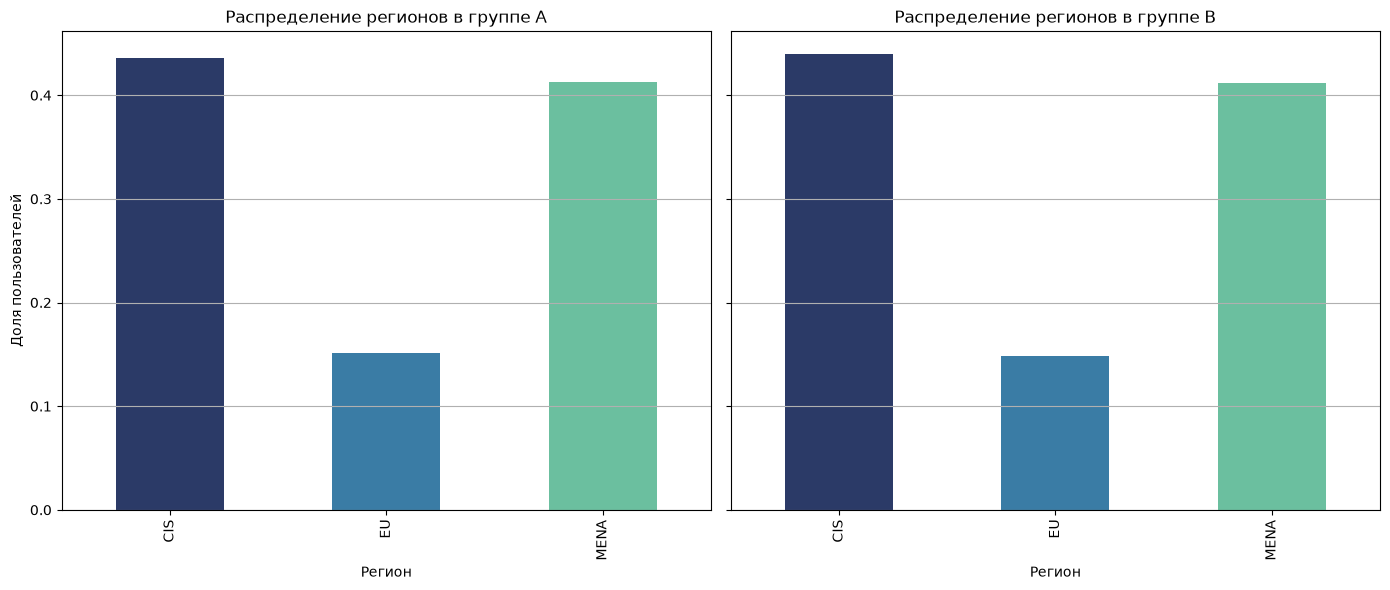

In [33]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Цвета для визуализации
colors = ['#2B3A67', '#3A7CA5', '#6BBF9F']

# Группа A
region_a.plot(
    kind='bar',
    color=colors,
    ax=axes[0]
)

axes[0].set_title('Распределение регионов в группе A')
axes[0].set_xlabel('Регион')
axes[0].set_ylabel('Доля пользователей')
axes[0].grid(axis='y')

# Группа B
region_b.plot(
    kind='bar',
    color=colors,
    ax=axes[1]
)

axes[1].set_title('Распределение регионов в группе B')
axes[1].set_xlabel('Регион')
axes[1].set_ylabel('Доля пользователей')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

#### Промежуточный вывод по результатам проверки равномерности распределения по регионам

По построенным диаграммам видно, что доли пользователей из каждого региона в группах A и B практически совпадают. 

Существенного дисбаланса по регионам не выявлено. Это свидетельствует о том, что рандомизация выполнена корректно и пользователи распределены между группами равномерно по региональному признаку.

Следовательно, регион пользователя не должен оказывать заметного влияния на результаты сравнения тестовой и контрольной групп.

#### Вывод по результатам проверки A/B-теста
- Различие в количестве пользователей между группами составляет менее 1%, что является незначительным и находится в пределах допустимого отклонения для A/B-теста. Существенного дисбаланса между группами не обнаружено.
- Пересечение пользователей между тестовой и контрольной группами отсутствует. Каждый пользователь присутствует только в одной группе, поэтому выборки являются независимыми.
- После пересчёта распределения по уникальным пользователям было установлено, что распределение пользователей по типам устройств в группах A и B практически совпадает. Существенных различий между группами не наблюдается.
- Аналогично распределение пользователей по регионам среди уникальных пользователей также оказалось сбалансированным. Доли пользователей из различных регионов в группах A и B отличаются незначительно и находятся в пределах случайных колебаний.
- Проверка основных требований к проведению эксперимента показала отсутствие нарушений рандомизации и проблем с формированием групп.

**Таким образом**, A/B-тест проводится корректно. Группы сопоставимы по количеству пользователей, независимы друг от друга и сбалансированы по ключевым категориальным признакам (устройствам и регионам). Полученные результаты эксперимента можно считать надёжными и использовать для дальнейшего анализа эффективности нового алгоритма.


# Оценка результатов и проверка гипотез

### Получение результатов теста и подсчёт основной метрики

In [34]:
# Данные за весь период эксперимента (sessions_test)
# Создаём признак успешной сессии
sessions_test['good_session'] = (
    sessions_test['page_counter'] >= 4
).astype(int)

sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


### Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

#### Формулировка гипотез

Нулевая гипотеза (H₀):

- Новый алгоритм рекомендаций не влияет на долю успешных первых сессий пользователей. Доля успешных первых сессий в группах A и B статистически не различается.

Альтернативная гипотеза (H₁):

- Новый алгоритм рекомендаций влияет на долю успешных первых сессий пользователей. Доля успешных первых сессий в группе B отличается от доли успешных первых сессий в группе A.

#### Целевая метрика

-  В качестве целевой метрики выбрана доля успешных первых сессий пользователей (доля сессий, в которых было просмотрено не менее четырёх страниц контента).

Данная метрика напрямую отражает заинтересованность пользователей контентом и качество рекомендательной системы.

#### Прокси-метрики

В качестве прокси-метрик можно использовать:

- среднее количество просмотренных страниц за сессию;
- среднюю длительность сессии;
- долю зарегистрировавшихся пользователей;
- количество повторных визитов пользователей.

#### Барьерные метрики

В качестве барьерных метрик можно использовать:

- выручку от рекламы;
- долю пользователей, оформивших подписку;
- удержание пользователей (Retention);
- количество технических ошибок приложения;
- скорость загрузки контента.

### Сравнение доли успешных первых сессий

In [35]:
# Оставляем только первые сессии пользователей
first_sessions = sessions_test[
    sessions_test['session_number'] == 1
].copy()

# Доля успешных первых сессий по группам
good_session_share = (
    first_sessions.groupby('test_group')['good_session']
    .mean()
)

good_session_share

test_group
A    0.315724
B    0.314673
Name: good_session, dtype: float64

In [36]:
# Успешные первые сессий в группе A
share_a = good_session_share['A']

# Успешные первые сессий в группе B
share_b = good_session_share['B']

# Разница успешных первых сессий в группе A и B
difference = share_b - share_a

print(f'Доля успешных первых сессий в группе A: {share_a:.4f}')
print(f'Доля успешных первых сессий в группе B: {share_b:.4f}')
print(f'Разница между группами: {difference:.4f}')

Доля успешных первых сессий в группе A: 0.3157
Доля успешных первых сессий в группе B: 0.3147
Разница между группами: -0.0011


### Рассчет статистической значимости изменений ключевой метрики

In [37]:
# Считаем количество успешных первых сессий в каждой группе
successes = (
    first_sessions.groupby('test_group')['good_session']
    .sum()
)
successes

test_group
A    4787
B    4851
Name: good_session, dtype: int64

In [38]:
# Считаем количество первых сессий в каждой группе
observations = (
    first_sessions.groupby('test_group')['good_session']
    .count()
)
observations

test_group
A    15162
B    15416
Name: good_session, dtype: int64

In [39]:
# Проводим Z-тест для сравнения двух долей
stat, p_value = proportions_ztest(
    count=successes,
    nobs=observations
)

# Выводим результаты теста
print(f'Z-статистика: {stat:.4f}')
print(f'p-value: {p_value:.4f}')

# Интерпретируем результат
alpha = 0.05

if p_value < alpha:
    print('Различие между группами статистически значимо.')
    print('Нулевая гипотеза отвергается.')
else:
    print('Статистически значимых различий между группами не обнаружено.')
    print('Нет оснований отвергнуть нулевую гипотезу.')

Z-статистика: 0.1977
p-value: 0.8433
Статистически значимых различий между группами не обнаружено.
Нет оснований отвергнуть нулевую гипотезу.


#### Промежуточный вывод по результатам проверки статистической значимости изменения ключевой метрики

**p-value = 0.8433 > 0.05**
- Вероятность случайно получить наблюдаемую разницу (или более экстремальную) при условии, что на самом деле эффекта нет, составляет 84.33%

**Статистическая значимость:**
- Различие между группами не является статистически значимым
- Нет оснований отвергнуть нулевую гипотезу (H₀)

**Новый алгоритм рекомендаций не привел к статистически значимому изменению доли успешных первых сессий.**
- Несмотря на то, что в абсолютном выражении группа B показала результат на 0.11 процентных пункта ниже группы A, это различие находится в пределах статистической погрешности и не может считаться значимым.

---
# Итоговый вывод и рекомендации

#### Характеристики проведённого эксперимента

Эксперимент проводился в период с 14 октября по 2 ноября 2025 года. В тестировании участвовало 30 578 пользователей, разделённых на контрольную группу A (старый алгоритм рекомендаций) и тестовую группу B (новый алгоритм рекомендаций).

На этапе планирования был выполнен расчёт размера выборки при уровне значимости 0.05, мощности теста 80% и минимальном детектируемом эффекте (MDE), равном 3% от базового значения метрики. Расчёт показал необходимость набора около 41 040 пользователей в каждую группу. 

Фактический объём выборки оказался меньше расчётного значения. Это связано с ограниченным трафиком в период проведения теста: эксперимент проводился в фиксированные сроки, и увеличение длительности требовало дополнительного согласования. Таким образом, выборка была ограничена доступным объёмом пользователей, а не технической возможностью его увеличить.

#### Влияние нового алгоритма на ключевую метрику

Ключевой метрикой эксперимента являлась доля успешных первых сессий - доля новых пользователей, просмотревших не менее четырёх страниц контента в первой сессии.

По результатам теста:
- в группе A доля успешных первых сессий составила 31.57%;
- в группе B доля успешных первых сессий составила 31.47%.

Разница между группами составила −0.11 процентного пункта. Новый алгоритм не продемонстрировал улучшения ключевой метрики относительно текущего решения.

#### Статистическая значимость результата

Для проверки статистической значимости различий был проведён двухвыборочный z-тест для сравнения долей.

Полученное значение:
- p-value = 0.8433.

Так как p-value значительно превышает уровень значимости α = 0.05, оснований отвергать нулевую гипотезу нет. Статистически значимых различий между группами обнаружено не было.

--- 

#### Рекомендация по внедрению

На основании проведённого анализа внедрение нового алгоритма рекомендаций в текущем виде нецелесообразно.

Эксперимент не выявил статистически значимого улучшения ключевой метрики - доли успешных первых сессий (p-value = 0.8433 при α = 0.05). Более того, наблюдаемое изменение оказалось отрицательным (−0.11 п.п.) и находится в пределах случайных колебаний, что не позволяет сделать вывод о превосходстве нового алгоритма над текущим решением.

**Дальнейшие шаги:**

- Доработка алгоритма. Рекомендуется провести дополнительный анализ поведения пользователей в тестовой группе, чтобы выявить возможные сценарии, где новый алгоритм показывает улучшение, и точечно доработать его перед повторным тестированием.

- Увеличение выборки. При повторном эксперименте целесообразно обеспечить набор расчётного объёма выборки (41 040 пользователей на группу) для достижения достаточной статистической мощности. Это может потребовать увеличения длительности теста или привлечения дополнительного трафика.

- Сегментный анализ. Рекомендуется проверить эффективность алгоритма на отдельных сегментах пользователей (по региону, типу устройства, источнику трафика). Возможно, алгоритм показывает улучшение на определённых группах, но эффект нивелируется на общем пуле.

- Оценка прокси-метрик. При повторном тестировании рекомендуется включить дополнительные прокси-метрики (время на сессию, глубина просмотра, доля повторных визитов) и барьерные метрики (конверсия в подписку, рекламные доходы) для более комплексной оценки влияния алгоритма на продукт.

**Таким образом**, в текущей реализации новый алгоритм не даёт значимого эффекта, и его внедрение не рекомендуется. При наличии доработанной версии алгоритма или увеличенной выборки эксперимент может быть проведён повторно.